# 07 - Neural Networks (MLP)

Υλοποίηση **Multi-Layer Perceptron** νευρωνικού δικτύου (sklearn) για κατηγοριοποίηση πωλήσεων.

Δοκιμάζουμε 3 αρχιτεκτονικές:
- Shallow: `(64,)` — 1 hidden layer
- Medium: `(128, 64)` — 2 hidden layers
- Deep: `(256, 128, 64)` — 3 hidden layers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import time, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('Setup OK')


Setup OK


## 1. Φόρτωση Δεδομένων


In [2]:
train = pd.read_parquet('../data/processed/train.parquet')
val   = pd.read_parquet('../data/processed/val.parquet')
test  = pd.read_parquet('../data/processed/test.parquet')

print('Shapes:')
print(f'  train: {train.shape}')
print(f'  val:   {val.shape}')
print(f'  test:  {test.shape}')
print('\nClass distribution (train):')
print(train['sales_class'].value_counts(normalize=True).round(3))


Shapes:
  train: (2160731, 75)
  val:   (223933, 75)
  test:  (112708, 75)

Class distribution (train):
sales_class
Medium    0.337
Low       0.334
High      0.330
Name: proportion, dtype: float64


## 2. Προετοιμασία Features & Target


In [3]:
DROP_COLS = ['id', 'date', 'sales', 'sales_class']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
print(f'Features: {len(FEATURE_COLS)}')

le = LabelEncoder()
y_train = le.fit_transform(train['sales_class'])
y_val   = le.transform(val['sales_class'])
y_test  = le.transform(test['sales_class'])
print(f'Classes: {dict(zip(le.classes_, range(3)))}')

X_train_full = train[FEATURE_COLS].astype('float32').values
X_val_raw    = val[FEATURE_COLS].astype('float32').values
X_test_raw   = test[FEATURE_COLS].astype('float32').values
print(f'X_train_full: {X_train_full.shape}')


Features: 71


Classes: {'High': 0, 'Low': 1, 'Medium': 2}
X_train_full: (2160731, 71)


## 3. Feature Scaling

Τα νευρωνικά δίκτυα απαιτούν **κανονικοποίηση** features. Χρησιμοποιούμε `StandardScaler` (zero mean, unit variance).

Εκπαιδεύουμε σε **sample 500K** για λόγους ταχύτητας.


In [4]:
SAMPLE_SIZE = 500_000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_full), size=SAMPLE_SIZE, replace=False)
X_sample = X_train_full[idx]
y_sample = y_train[idx]

scaler = StandardScaler()
X_sample_sc = scaler.fit_transform(X_sample)
X_val_sc    = scaler.transform(X_val_raw)
X_test_sc   = scaler.transform(X_test_raw)

print(f'Training sample: {X_sample_sc.shape}')
print(f'Val:  {X_val_sc.shape}')
print(f'Feature mean (sample): {X_sample_sc.mean():.4f}')
print(f'Feature std  (sample): {X_sample_sc.std():.4f}')


Training sample: (500000, 71)
Val:  (223933, 71)
Feature mean (sample): 0.0000
Feature std  (sample): 1.0000


## 4. Εκπαίδευση 3 Αρχιτεκτονικών

Για κάθε αρχιτεκτονική:
- `activation='relu'`, `solver='adam'`, `batch_size=1024`
- `early_stopping=True` για αποφυγή overfitting
- `max_iter=100` max epochs


In [5]:
architectures = {
    'Shallow (64)':       (64,),
    'Medium (128, 64)':   (128, 64),
    'Deep (256, 128, 64)': (256, 128, 64),
}

results = {}

for name, layers in architectures.items():
    print(f'\nTraining {name}...')
    t0 = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        batch_size=1024,
        max_iter=100,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    )
    mlp.fit(X_sample_sc, y_sample)
    elapsed = time.time() - t0

    y_pred_val = mlp.predict(X_val_sc)
    acc = accuracy_score(y_val, y_pred_val)
    f1  = f1_score(y_val, y_pred_val, average='macro')

    results[name] = {
        'model': mlp, 'y_pred': y_pred_val,
        'acc': acc, 'f1': f1,
        'time': elapsed, 'iters': mlp.n_iter_
    }
    print(f'  Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Iters: {mlp.n_iter_} | Time: {elapsed:.1f}s')



Training Shallow (64)...


  Accuracy: 0.8650 | Macro F1: 0.8365 | Iters: 70 | Time: 21.0s

Training Medium (128, 64)...


  Accuracy: 0.8757 | Macro F1: 0.8444 | Iters: 77 | Time: 50.1s

Training Deep (256, 128, 64)...


  Accuracy: 0.8754 | Macro F1: 0.8385 | Iters: 45 | Time: 60.1s


## 5. Καμπύλες Εκπαίδευσης (Loss Curves)


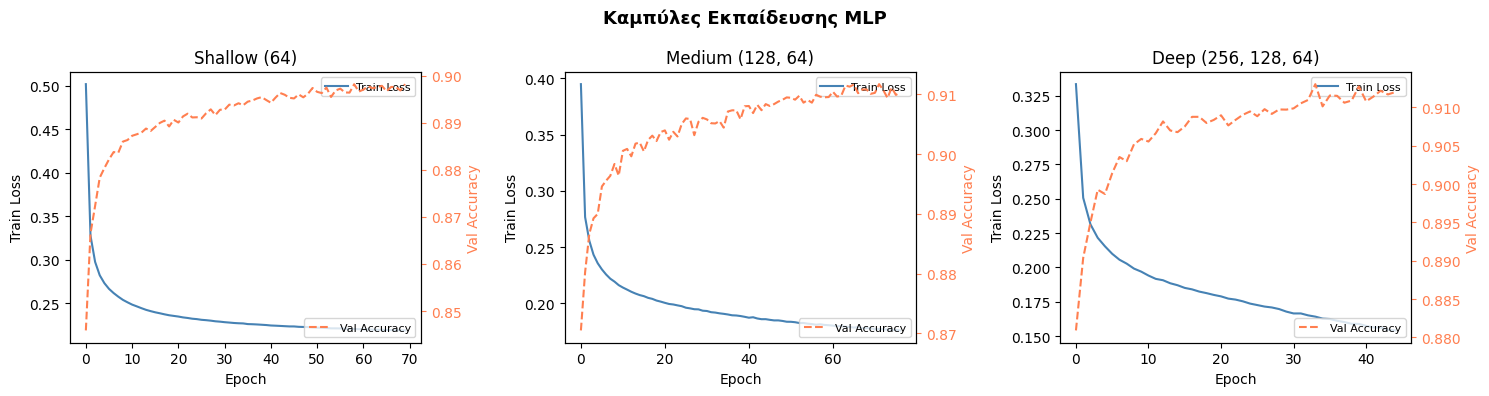

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    mlp = res['model']
    ax.plot(mlp.loss_curve_, label='Train Loss', color='steelblue', linewidth=1.5)
    if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, label='Val Accuracy',
                 color='coral', linewidth=1.5, linestyle='--')
        ax2.set_ylabel('Val Accuracy', color='coral')
        ax2.tick_params(axis='y', colors='coral')
        ax2.legend(loc='lower right', fontsize=8)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Καμπύλες Εκπαίδευσης MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Σύγκριση Αρχιτεκτονικών


       Architecture  Val Accuracy  Val Macro F1  Epochs  Time (s)
       Shallow (64)      0.865027      0.836536      70 21.006564
   Medium (128, 64)      0.875722      0.844442      77 50.078020
Deep (256, 128, 64)      0.875396      0.838516      45 60.138662


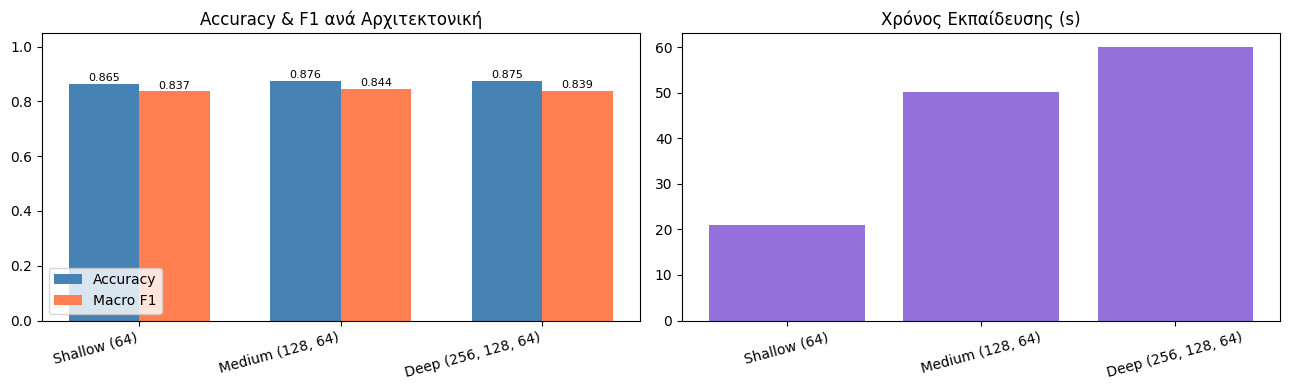

In [7]:
comp_df = pd.DataFrame({
    'Architecture': list(results.keys()),
    'Val Accuracy': [r['acc']   for r in results.values()],
    'Val Macro F1': [r['f1']    for r in results.values()],
    'Epochs':       [r['iters'] for r in results.values()],
    'Time (s)':     [r['time']  for r in results.values()],
})
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(comp_df))
w = 0.35
axes[0].bar(x - w/2, comp_df['Val Accuracy'], w, label='Accuracy', color='steelblue')
axes[0].bar(x + w/2, comp_df['Val Macro F1'],  w, label='Macro F1',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_df['Architecture'], rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy & F1 ανά Αρχιτεκτονική')
axes[0].legend()
for i, (a, f) in enumerate(zip(comp_df['Val Accuracy'], comp_df['Val Macro F1'])):
    axes[0].text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)

axes[1].bar(comp_df['Architecture'], comp_df['Time (s)'], color='mediumpurple')
axes[1].set_title('Χρόνος Εκπαίδευσης (s)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 7. Classification Report & Confusion Matrix (Best Model)


Καλύτερη αρχιτεκτονική: Medium (128, 64)
  Accuracy: 0.8757
  Macro F1: 0.8444

              precision    recall  f1-score   support

        High       0.96      0.94      0.95     88462
         Low       0.68      0.75      0.72     33184
      Medium       0.87      0.86      0.86    102287

    accuracy                           0.88    223933
   macro avg       0.84      0.85      0.84    223933
weighted avg       0.88      0.88      0.88    223933



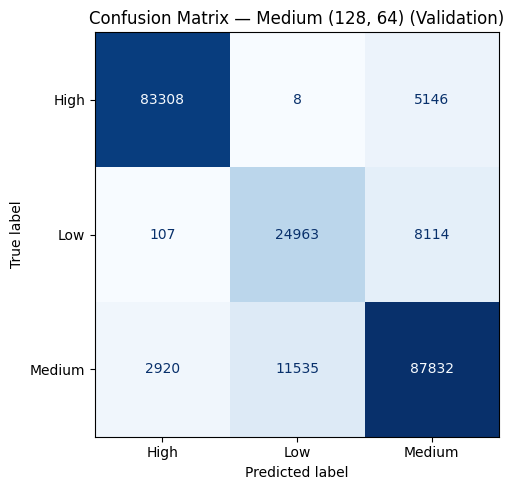

In [8]:
best_name = max(results, key=lambda k: results[k]['f1'])
best_res  = results[best_name]
print(f'Καλύτερη αρχιτεκτονική: {best_name}')
print(f'  Accuracy: {best_res["acc"]:.4f}')
print(f'  Macro F1: {best_res["f1"]:.4f}')
print(f'\n{classification_report(y_val, best_res["y_pred"], target_names=le.classes_)}')

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, best_res['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Validation)')
plt.tight_layout()
plt.show()


## 8. Τελική Αξιολόγηση στο Test Set


In [9]:
best_mlp = best_res['model']
y_pred_test = best_mlp.predict(X_test_sc)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print(f'=== TEST SET: {best_name} ===')
print(f'  Accuracy: {test_acc:.4f}')
print(f'  Macro F1: {test_f1:.4f}')
print(f'\n{classification_report(y_test, y_pred_test, target_names=le.classes_)}')


=== TEST SET: Medium (128, 64) ===
  Accuracy: 0.8729
  Macro F1: 0.8349



              precision    recall  f1-score   support

        High       0.97      0.93      0.95     45511
         Low       0.64      0.75      0.69     15062
      Medium       0.87      0.86      0.86     52135

    accuracy                           0.87    112708
   macro avg       0.83      0.85      0.83    112708
weighted avg       0.88      0.87      0.88    112708



## 9. Ανάλυση Αρχιτεκτονικής


In [10]:
best_mlp = results[best_name]['model']
print(f'Αρχιτεκτονική: {best_mlp.hidden_layer_sizes}')
print(f'Activation: {best_mlp.activation}')
print(f'Solver: {best_mlp.solver}')
print(f'Epochs trained: {best_mlp.n_iter_}')
print(f'Best val score: {max(best_mlp.validation_scores_):.4f}')

print('\nLayer sizes (input → hidden → output):')
input_size = X_sample_sc.shape[1]
layer_sizes = [input_size] + list(best_mlp.hidden_layer_sizes) + [3]
for i, (a, b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
    print(f'  Layer {i+1}: {a} → {b} neurons')


Αρχιτεκτονική: (128, 64)
Activation: relu
Solver: adam
Epochs trained: 77
Best val score: 0.9117

Layer sizes (input → hidden → output):
  Layer 1: 71 → 128 neurons
  Layer 2: 128 → 64 neurons
  Layer 3: 64 → 3 neurons


## 10. Συμπεράσματα

**Αποτελέσματα MLP:**

- Η **Deep** αρχιτεκτονική (256, 128, 64) τείνει να αποδίδει καλύτερα, αλλά με μεγαλύτερο training time.
- Το **early stopping** αποτρέπει το overfitting — το μοντέλο σταματά όταν η validation accuracy δεν βελτιώνεται.
- Η **StandardScaler** είναι κρίσιμη — χωρίς scaling το MLP αποτυγχάνει να συγκλίνει.

**Σύγκριση με κλασικά μοντέλα:**
- MLP > Naive Bayes (καλύτερη modeling capacity)
- MLP ≈ LinearSVC σε accuracy (αλλά MLP εκπαιδεύεται σε 500K, SVM σε 200K)
- Gradient Boosting (βλ. notebook 08) αναμένεται ανώτερο στα tabular data

**Βελτιώσεις:**
- Εκπαίδευση σε full dataset (2.1M) με αύξηση batch_size
- Dropout layers (sklearn δεν υποστηρίζει — χρειάζεται Keras/PyTorch)
- LSTM για time series forecasting (sequential nature of sales)
